EQN du/dt = u  , u(0) = 1 on [0,1] true answer is e^t for checking

#CHUNK1 - IMPORTS

In [8]:

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)

In [ ]:
t = torch.linspace(0,1,100).reshape(-1,1)
t.requires_grad_(True);

In [10]:
net = nn.Sequential(nn.Linear(1,32),
                    nn.Tanh(),
                    nn.Linear(32, 32),
                    nn.Tanh(),
                    nn.Linear(32, 1))

In [11]:
def u(t):
    return 1.0 + t * net(t)

In [12]:
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)

In [13]:
for epoch in range(5000):
    optimizer.zero_grad()

    u_val = u(t)

    du_dt = torch.autograd.grad(
        u_val, t,
        grad_outputs=torch.ones_like(u_val),
        create_graph=True
    )[0]

    residual = du_dt - u_val
    loss = (residual ** 2).mean()

    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(epoch, loss.item())

0 0.8329086303710938
500 7.349502993747592e-05
1000 5.395893094828352e-05
1500 3.555144212441519e-05
2000 2.0381476133479737e-05
2500 9.461059562454466e-06
3000 2.886315996875055e-06
3500 6.313714493444422e-07
4000 3.112438946573093e-07
4500 2.83344832041621e-07


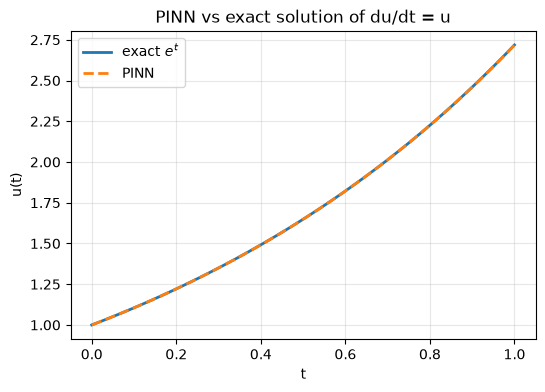

max error: 6.175041e-05


In [14]:
import matplotlib.pyplot as plt

t_test = torch.linspace(0, 1, 100).reshape(-1, 1)

with torch.no_grad():
    u_pred = 1.0 + t_test * net(t_test)

u_true = torch.exp(t_test)

t_np = t_test.numpy().flatten()
u_pred_np = u_pred.numpy().flatten()
u_true_np = u_true.numpy().flatten()

plt.figure(figsize=(6, 4))
plt.plot(t_np, u_true_np, label='exact $e^t$', linewidth=2)
plt.plot(t_np, u_pred_np, '--', label='PINN', linewidth=2)
plt.xlabel('t')
plt.ylabel('u(t)')
plt.legend()
plt.title('PINN vs exact solution of du/dt = u')
plt.grid(alpha=0.3)
plt.show()

print("max error:", abs(u_pred_np - u_true_np).max())